In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

# Check your folder structure first
base_path = '/content/drive/MyDrive/Flickr8k data sn'
print(os.listdir(base_path))

['archive (6).zip', 'features.pkl', 'model_epoch_20.h5', 'model_epoch_21.h5', 'model_epoch_22.h5', 'model_epoch2_1.h5', 'model_epoch2_2.h5', 'model_epoch2_3.h5', 'model_epoch2_4.h5', 'model_epoch2_5.h5', 'model_epoch2_6.h5', 'model_epoch2_7.h5', 'model_epoch2_8.h5', 'model_epoch2_9.h5', 'model_epoch2_10.h5', 'model_epoch2_11.h5', 'model_epoch2_12.h5', 'model_epoch2_13.h5', 'model_epoch2_14.h5', 'model_epoch2_15.h5', 'model_epoch2_16.h5', 'model_epoch2_17.h5', 'model_epoch2_18.h5', 'model_epoch2_19.h5', 'model_epoch2_20.h5', 'loss_graph.png', 'tokenizer.pkl', 'model_architecture.png', 'model_epoch_2.h5', 'model_epoch_3.h5', 'model_epoch_4.h5', 'model_epoch_5.h5', 'model_epoch_6.h5', 'model_epoch_7.h5', 'model_epoch_8.h5', 'model_epoch_9.h5', 'model_epoch_10.h5', 'model_epoch_11.h5', 'model_epoch_12.h5', 'model_epoch_13.h5', 'model_epoch_14.h5', 'model_epoch_15.h5', 'model_epoch_16.h5', 'model_epoch_17.h5', 'model_epoch_18.h5', 'model_epoch_19.h5', 'model_epoch_1.h5']


In [3]:
import zipfile
import os

zip_file = '/content/drive/MyDrive/Flickr8k data sn/archive (6).zip'
extract_path = '/content/flickr8k'

print("Extracting... please wait")
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done! Files extracted:")
print(os.listdir(extract_path))

Extracting... please wait
Done! Files extracted:
['Images', 'captions.txt']


In [4]:
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

BASE_DIR = '/content/flickr8k'
WORKING_DIR = '/content/working'

os.makedirs(WORKING_DIR, exist_ok=True)
print("All imports done!")
print("Images folder:", os.listdir(os.path.join(BASE_DIR, 'Images'))[:5])

All imports done!
Images folder: ['624742559_ff467d8ebc.jpg', '438639005_208bc59b0b.jpg', '3612538549_2828b45867.jpg', '3292016893_24d14c8b4f.jpg', '2931254547_e97c6d0d63.jpg']


In [5]:
# load vgg16 model
model = VGG16()
# restructure the model
model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
# summarize
print(model.summary())

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# extract features from image
features = {}
directory = os.path.join(BASE_DIR, 'Images')

for img_name in tqdm(os.listdir(directory)):
    # load the image from file
    img_path = directory + '/' + img_name
    image = load_img(img_path, target_size=(224, 224))
    # convert image pixels to numpy array
    image = img_to_array(image)
    # reshape data for model
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    # preprocess image for vgg
    image = preprocess_input(image)
    # extract features
    feature = model.predict(image, verbose=0)
    # get image ID
    image_id = img_name.split('.')[0]
    # store feature
    features[image_id] = feature

In [6]:
with open('/content/drive/MyDrive/Flickr8k data sn/features.pkl', 'rb') as f:
    features = pickle.load(f)

print(f"Features loaded: {len(features)}")

Features loaded: 8091


In [7]:
# load captions
with open(os.path.join(BASE_DIR, 'captions.txt'), 'r') as f:
    next(f)
    captions_doc = f.read()

# mapping
mapping = {}
for line in tqdm(captions_doc.split('\n')):
    tokens = line.split(',')
    if len(line) < 2:
        continue
    image_id, caption = tokens[0], tokens[1:]
    image_id = image_id.split('.')[0]
    caption = " ".join(caption)
    if image_id not in mapping:
        mapping[image_id] = []
    mapping[image_id].append(caption)

# clean
def clean(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            caption = captions[i]
            caption = caption.lower()
            caption = caption.replace('[^A-Za-z]', '')
            caption = caption.replace('\s+', ' ')
            caption = 'startseq ' + " ".join([word for word in caption.split() if len(word)>1]) + ' endseq'
            captions[i] = caption

clean(mapping)

# tokenizer
all_captions = []
for key in mapping:
    for caption in mapping[key]:
        all_captions.append(caption)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in all_captions)

# save tokenizer
pickle.dump(tokenizer, open(os.path.join(WORKING_DIR, 'tokenizer.pkl'), 'wb'))

print(f"Vocab size: {vocab_size}")
print(f"Max length: {max_length}")

<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2735/728783473.py:26: SyntaxWarning: invalid escape sequence '\s'
  caption = caption.replace('\s+', ' ')


  0%|          | 0/40456 [00:00<?, ?it/s]

Vocab size: 8485
Max length: 35


In [8]:
# train test split
image_ids = list(mapping.keys())
split = int(len(image_ids) * 0.90)
train = image_ids[:split]
test = image_ids[split:]
print(f"Train: {len(train)}, Test: {len(test)}")

Train: 7281, Test: 810


In [9]:
# data generator
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    X1, X2, y = list(), list(), list()
    n = 0
    while 1:
        for key in data_keys:
            n += 1
            captions = mapping[key]
            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            if n == batch_size:
                X1, X2, y = np.array(X1), np.array(X2), np.array(y)
                yield {"image": X1, "text": X2}, y
                X1, X2, y = list(), list(), list()
                n = 0
print("Generator ready!")

Generator ready!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 35)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 4096)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 35, 256)   │  2,172,160 │ text[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4096)      │          0 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 35, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 35)        │          0 │ text[0][0]        │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8485)      │  2,180,645 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,992,741 (22.86 MB)

 Trainable params: 5,992,741 (22.86 MB)

 Non-trainable params: 0 (0.00 B)

None


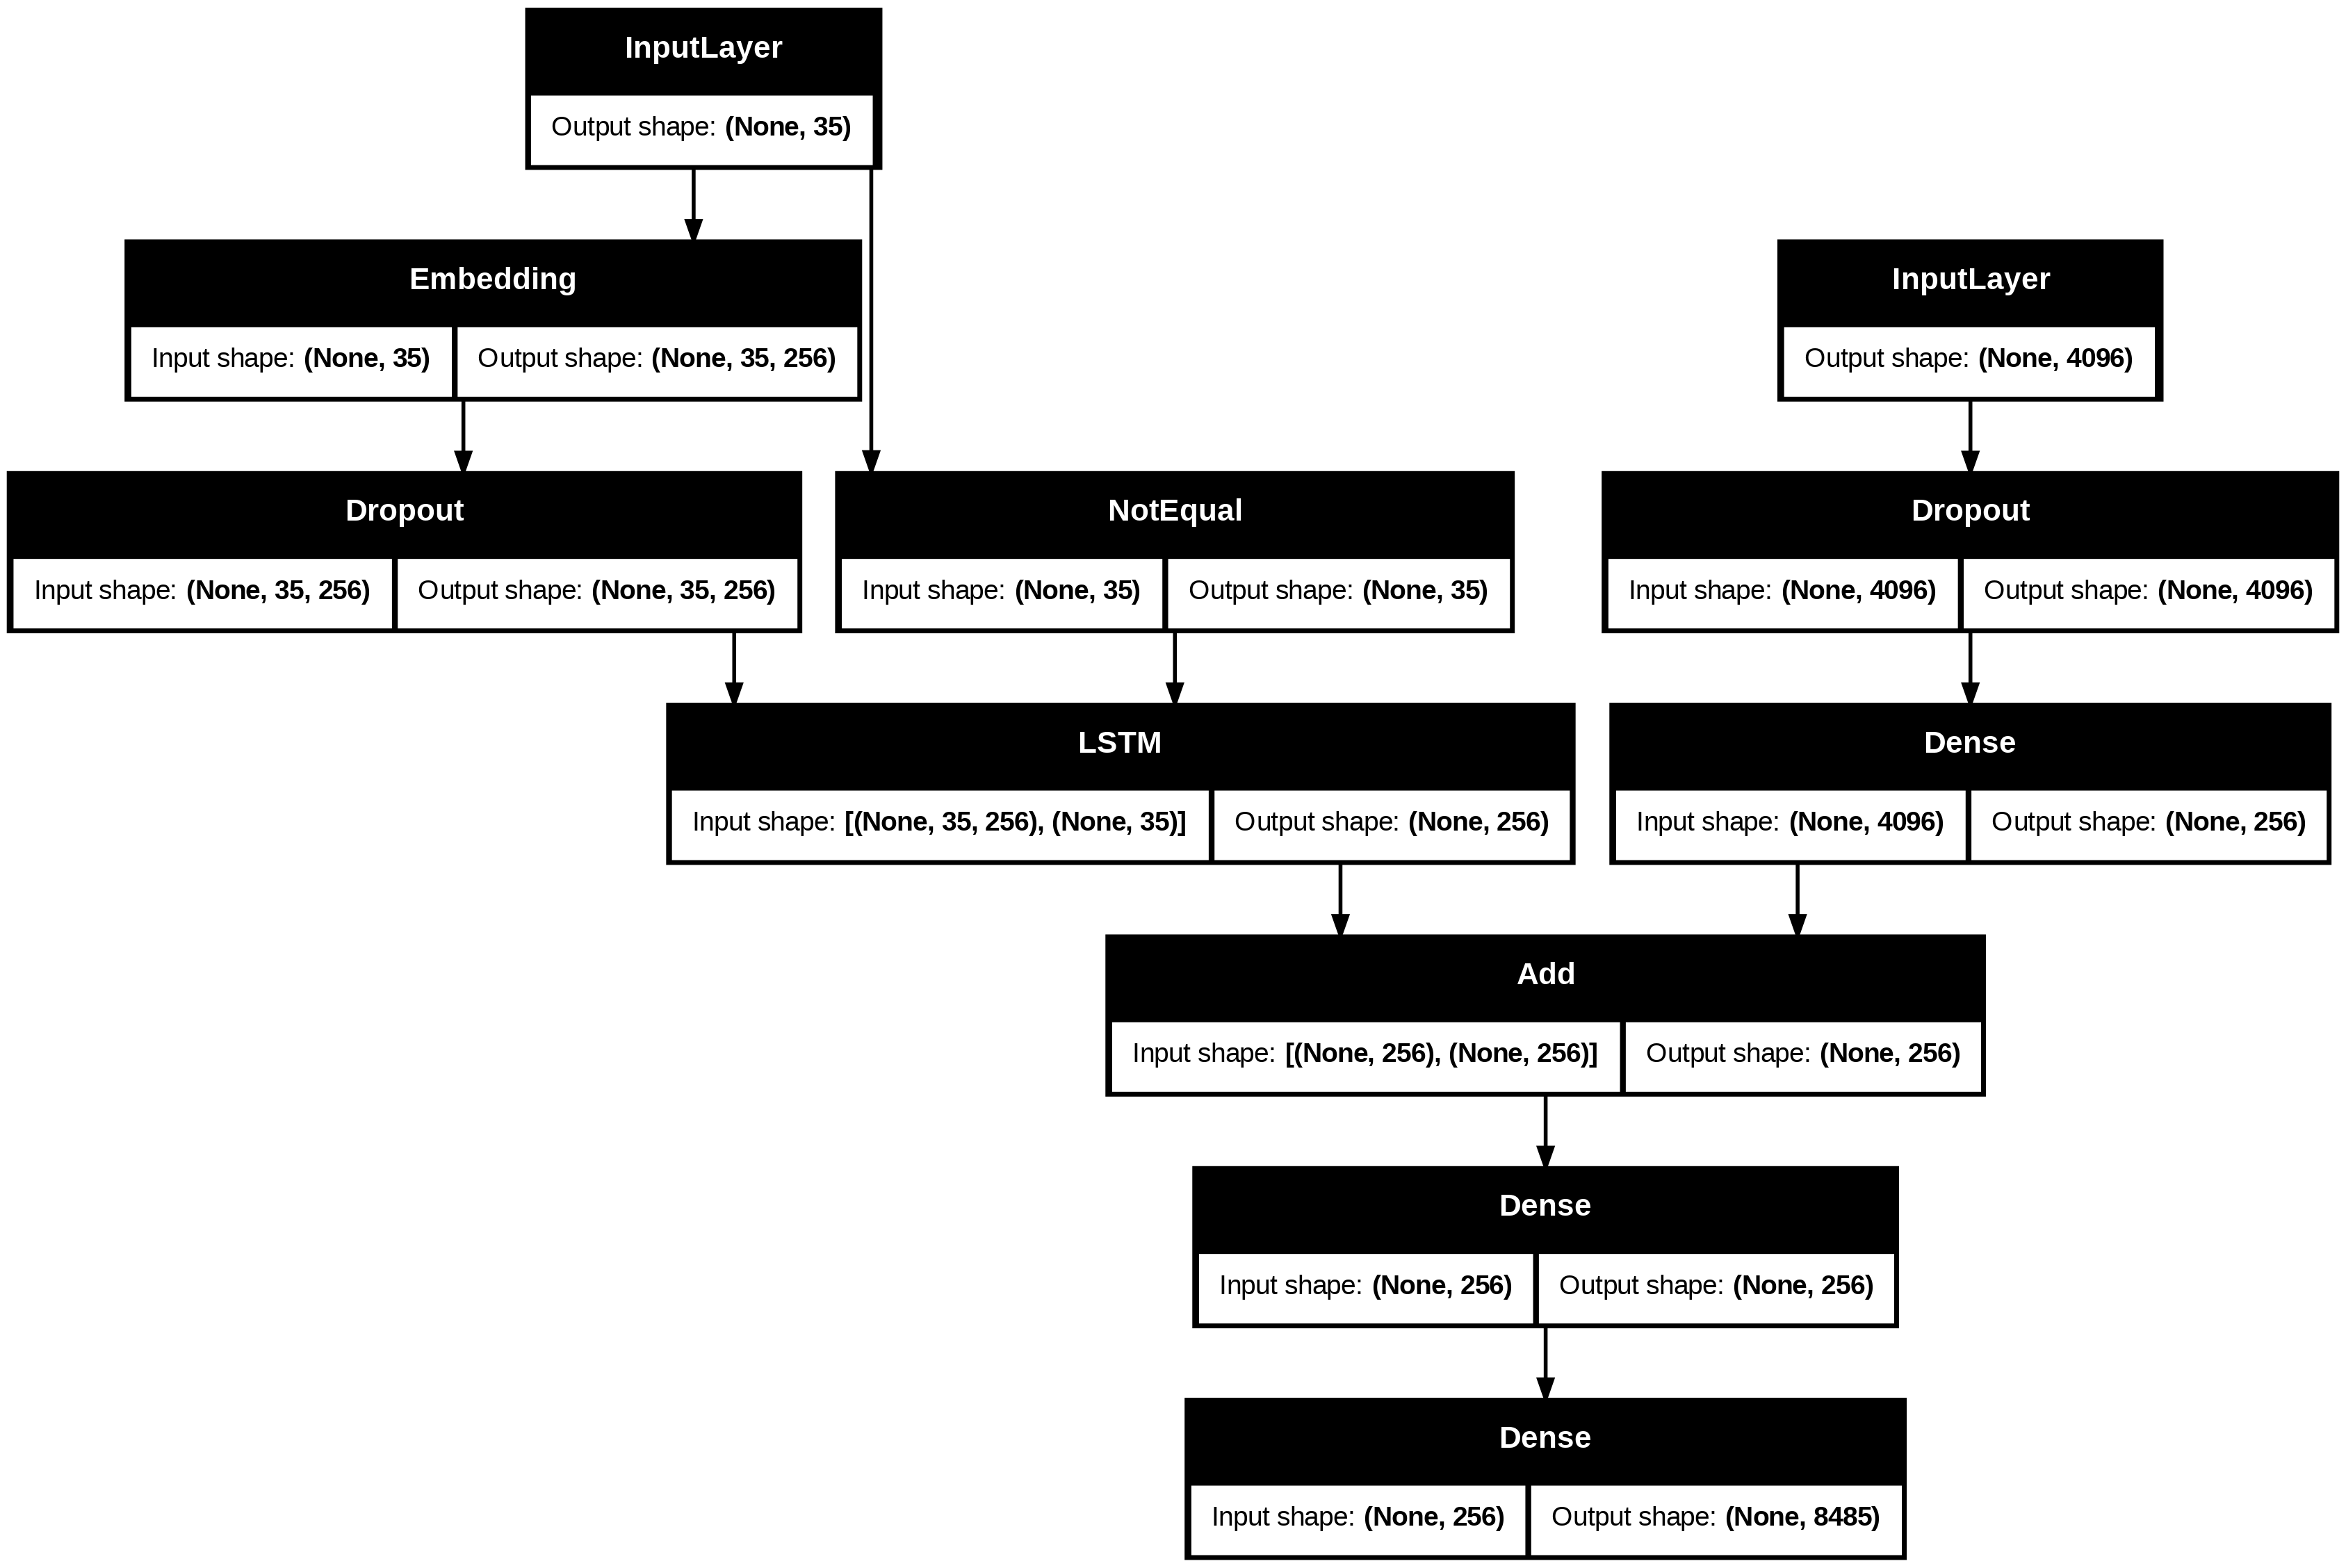

In [10]:
# build model
inputs1 = Input(shape=(4096,), name="image")
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

inputs2 = Input(shape=(max_length,), name="text")
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

print(model.summary())
plot_model(model, show_shapes=True)

In [11]:
# check if model was saved
import os
print(os.listdir(WORKING_DIR))

['tokenizer.pkl']


In [ ]:
epochs = 21
batch_size = 32
steps = len(train) // batch_size

for i in range(epochs):
    generator = data_generator(train, mapping, features, tokenizer, max_length, vocab_size, batch_size)
    model.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)
    print(f"Epoch {i+1} completed!")
    # save after EVERY epoch to Drive
    model.save(f'/content/drive/MyDrive/Flickr8k data sn/model_epoch_{i+1}.h5')
    print(f"✅ Model saved to Drive - Epoch {i+1}!")

227/227 ━━━━━━━━━━━━━━━━━━━━ 59s 236ms/step - loss: 5.1362


Epoch 1 completed!
✅ Model saved to Drive - Epoch 1!
227/227 ━━━━━━━━━━━━━━━━━━━━ 53s 235ms/step - loss: 3.9263


Epoch 2 completed!
✅ Model saved to Drive - Epoch 2!
227/227 ━━━━━━━━━━━━━━━━━━━━ 53s 233ms/step - loss: 3.5110


Epoch 3 completed!
✅ Model saved to Drive - Epoch 3!
227/227 ━━━━━━━━━━━━━━━━━━━━ 53s 234ms/step - loss: 3.2472


Epoch 4 completed!
✅ Model saved to Drive - Epoch 4!
227/227 ━━━━━━━━━━━━━━━━━━━━ 52s 228ms/step - loss: 3.0568


...

Epoch 18 completed!
✅ Model saved to Drive - Epoch 18!
227/227 ━━━━━━━━━━━━━━━━━━━━ 54s 239ms/step - loss: 2.1765


Epoch 19 completed!
✅ Model saved to Drive - Epoch 19!
227/227 ━━━━━━━━━━━━━━━━━━━━ 56s 245ms/step - loss: 2.1451


Epoch 20 completed!
✅ Model saved to Drive - Epoch 20!
227/227 ━━━━━━━━━━━━━━━━━━━━ 55s 243ms/step - loss: 2.1195


Epoch 21 completed!
✅ Model saved to Drive - Epoch 21!
227/227 ━━━━━━━━━━━━━━━━━━━━ 57s 249ms/step - loss: 2.0922


Epoch 22 completed!
✅ Model saved to Drive - Epoch 22!
 55/227 ━━━━━━━━━━━━━━━━━━━━ 50s 293ms/step - loss: 2.0848

In [12]:
# rebuild model architecture
inputs1 = Input(shape=(4096,), name="image")
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

inputs2 = Input(shape=(max_length,), name="text")
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')
print("Model rebuilt!")

Model rebuilt!


In [13]:
model.load_weights('/content/drive/MyDrive/Flickr8k data sn/model_epoch_21.h5')
print("Weights loaded from epoch 21!")

Weights loaded from epoch 21!


In [14]:
from nltk.translate.bleu_score import corpus_bleu

def idx_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def predict_caption(model, image, tokenizer, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], max_length, padding='post')
        yhat = model.predict([image, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = idx_to_word(yhat, tokenizer)
        if word is None:
            break
        in_text += " " + word
        if word == 'endseq':
            break
    return in_text

# evaluate
actual, predicted = list(), list()
for key in tqdm(test):
    captions = mapping[key]
    y_pred = predict_caption(model, features[key], tokenizer, max_length)
    actual_captions = [caption.split() for caption in captions]
    y_pred = y_pred.split()
    actual.append(actual_captions)
    predicted.append(y_pred)

print("BLEU-1: %f" % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2: %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))

  0%|          | 0/810 [00:00<?, ?it/s]

BLEU-1: 0.551411
BLEU-2: 0.323031


In [24]:
meteor_scores = []
for key in tqdm(test):
    captions = mapping[key]
    y_pred = predict_caption(model, features[key], tokenizer, max_length)
    # tokenize both
    references = [caption.split() for caption in captions]
    hypothesis = y_pred.split()
    meteor = meteor_score(references, hypothesis)
    meteor_scores.append(meteor)

avg_meteor = sum(meteor_scores) / len(meteor_scores)
print(f"BLEU-1: 0.551411")
print(f"BLEU-2: 0.323031")
print(f"METEOR: {avg_meteor:.6f}")

  0%|          | 0/810 [00:00<?, ?it/s]

BLEU-1: 0.551411
BLEU-2: 0.323031
METEOR: 0.380596


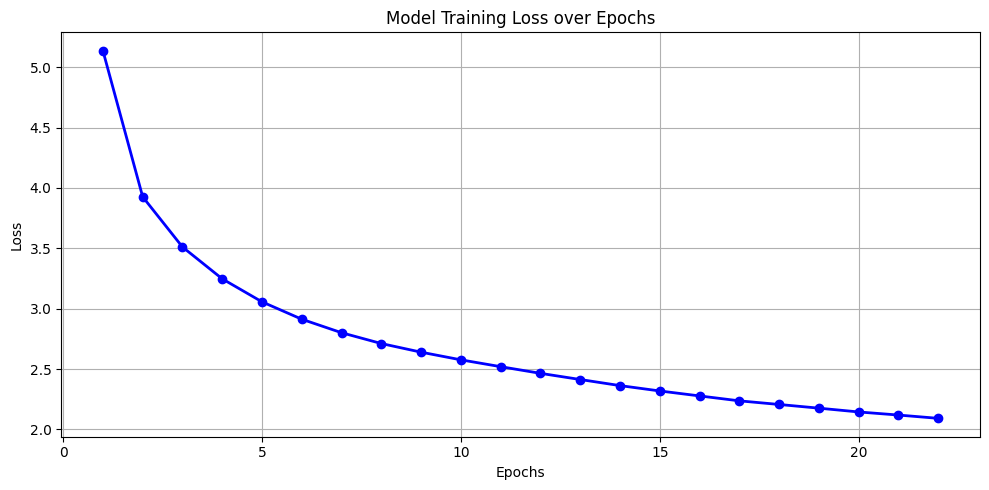

Loss graph saved to Drive!


In [16]:
import matplotlib.pyplot as plt

losses = [5.1362, 3.9263, 3.5110, 3.2472, 3.0568,
          2.9128, 2.8011, 2.7115, 2.6400, 2.5766,
          2.5200, 2.4648, 2.4137, 2.3633, 2.3189,
          2.2778, 2.2371, 2.2070, 2.1765, 2.1451,
          2.1195, 2.0922]

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses)+1), losses, marker='o', color='blue', linewidth=2)
plt.title('Model Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Flickr8k data sn/loss_graph.png', dpi=150)
plt.show()
print("Loss graph saved to Drive!")

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

def generate_caption(image_name):
    image_id = image_name.split('.')[0]
    img_path = os.path.join(BASE_DIR, "Images", image_name)
    image = Image.open(img_path)
    captions = mapping[image_id]
    print('---------------------Actual---------------------')
    for caption in captions:
        print(caption)
    y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
    print('--------------------Predicted--------------------')
    print(y_pred)
    plt.imshow(image)
    plt.axis('off')
    plt.show()



---------------------Actual---------------------
startseq an adult and child run on the beach endseq
startseq woman and little girl playing in the sand next to the ocean endseq
startseq two people run down the beach and one of them is pointing endseq
startseq two people running on beach endseq
startseq two people running on the shore of beach endseq
--------------------Predicted--------------------
startseq young girl in shorts and two shorts are running on the beach endseq


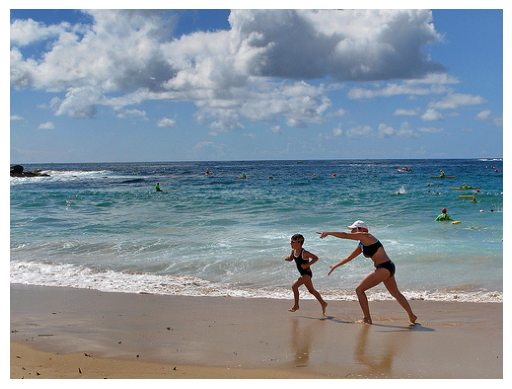

In [25]:
generate_caption("1982852140_56425fa7a2.jpg")

---------------------Actual---------------------
startseq black dog running in the surf endseq
startseq black lab with tags frolicks in the water endseq
startseq dog splashes in the water endseq
startseq the black dog runs through the water endseq
startseq this is black dog splashing in the water endseq
--------------------Predicted--------------------
startseq black dog with tags frolicks in the water endseq


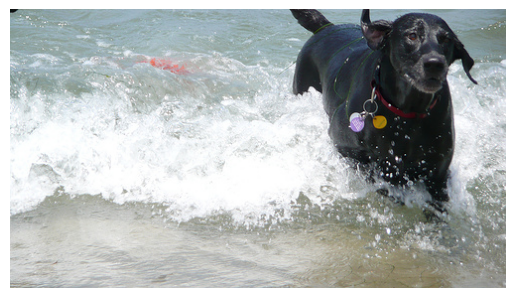

In [20]:
generate_caption("1022975728_75515238d8.jpg")

---------------------Actual---------------------
startseq child playing with fountain at the beach endseq
startseq child plays with fountain endseq
startseq girl looks at fountain that sprays water endseq
startseq little girl playing in water on frog sculpture endseq
startseq the little girl is playing with toy in public fountain endseq
--------------------Predicted--------------------
startseq girl in black shirt is playing with fountain endseq


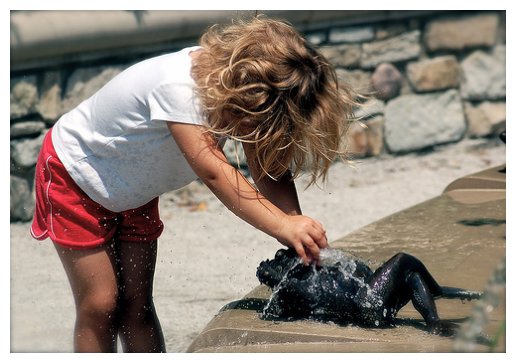

In [21]:
generate_caption("1115565519_d976d4b1f1.jpg")

---------------------Actual---------------------
startseq big brown dog is jumping in the water and has his mouth wide open endseq
startseq brown dog barks over its shoulder in the water endseq
startseq dog jumping in the water at beack endseq
startseq dog runs through the water as he looks up at the sky with his mouth open endseq
startseq dog with collar running through the water endseq
--------------------Predicted--------------------
startseq dog is playing in the water with ball in its mouth endseq


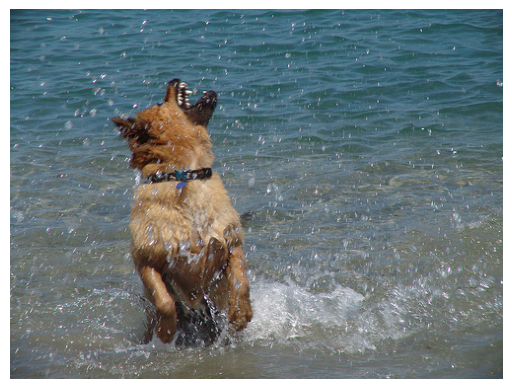

In [22]:
generate_caption("1287982439_6578006e22.jpg")